In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
df = pd.read_csv('OpenAlexData-4-21-2025.csv', index_col=0)

C:\Users\wieke\AppData\Local\Temp\ipykernel_35340\3233663523.py:1: DtypeWarning: Columns (8,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('OpenAlexData-4-21-2025.csv', index_col=0)


In [107]:
len(df)

517780

In [108]:
pd.set_option("display.max_columns", 55)


In [109]:
def counts(col1, col2, col3, df):
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col3] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]
    oa_count_s
    return oa_count_s.sort_values(by=[col3], ascending=False)
    



In [110]:
def multiple_counts(col1, col2, col3, col4, df):
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col4] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]

    
    return oa_count_s


In [111]:
def oa_status(df, col1, col2, sorted):
    oa_status_df = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_status_df = oa_status_df.fillna(0)
    oa_status_df['total'] = oa_status_df['bronze'] + oa_status_df['closed'] + oa_status_df['gold'] + oa_status_df['green'] + oa_status_df['hybrid']
    oa_status_df['hybrid %'] = oa_status_df['hybrid'] / oa_status_df['total']
    oa_status_df['green %'] = oa_status_df['green'] / oa_status_df['total']
    oa_status_df['gold %'] = oa_status_df['gold'] / oa_status_df['total']
    oa_status_df['closed %'] = oa_status_df['closed'] / oa_status_df['total']
    oa_status_df['bronze %'] = oa_status_df['bronze'] / oa_status_df['total']
    dct = {'hybrid %': 'hybrid', 'green %': 'green', 'gold %': 'gold', 'closed %': 'closed', 'bronze %': 'bronze'}
    oa_status_df['Most used OA type'] = oa_status_df[['hybrid %', 'green %', 'gold %', 'closed %', 'bronze %']].idxmax(axis=1).map(dct)

    #oa_status_df = oa_status_df.sort_values(by=[sort], ascending=False)
    oa_status_df = oa_status_df.sort_values(by=[sorted], ascending=False).reset_index(drop=True)

    return oa_status_df

In [112]:
def RadsCounts(col1, col2, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [113]:
def RadsMultipleCounts(col1, col2, col3, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [114]:
df.head()

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
0,https://openalex.org/W213417050,https://doi.org/10.1037/e675542012-001,dataset,funder,Cognitive Therapy for Depression,2012,2012-01-01,en,https://openalex.org/T11071,Treatment of Major Depression,https://openalex.org/subfields/2736,Pharmacology,https://openalex.org/fields/27,Medicine,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5059319052,Aaron T. Beck,last,https://orcid.org/0000-0001-6210-9528,https://openalex.org/I79576946,University of Pennsylvania,"Psychology,University of Pennsylvania",US,https://ror.org/00b30xv10,https://openalex.org/I79576946
1,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5025339678,John W. Creswell,first,https://orcid.org/0000-0002-5006-880X,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
2,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5021840711,Vicki L. Plano Clark,middle,https://orcid.org/0000-0002-9709-7982,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
3,https://openalex.org/W1639235375,https://doi.org/10.1037/e671332011-001,dataset,funder,The Loss of Sadness: How Psychiatry Transforme...,2009,2009-01-01,en,https://openalex.org/T12308,Mental Health and Psychiatry,https://openalex.org/subfields/1211,Philosophy,https://openalex.org/fields/12,Arts and Humanities,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5091505956,Jerome C. Wakefield,last,https://orcid.org/0000-0002-6809-5515,https://openalex.org/I57206974,New York University,"New York University, New York, NY, US",US,https://ror.org/0190ak572,https://openalex.org/I57206974
4,https://openalex.org/W2995669665,https://doi.org/10.1037/e555342011-003,dataset,funder,Cognitive Therapy for Depression,1996,1996-01-01,en,https://openalex.org/T13272,Psychological Treatments and Assessments,https://openalex.org/subfields/3203,Clinical Psychology,https://openalex.org/fields/32,Psychology,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5047792029,Aaron T. Beck,last,NaN,https://openalex.org/I79576946,University of Pennsylvania,"Department of Psychiatry, School of Medicine, ...",US,https://ror.org/00b30xv10,https://openalex.org/I79576946


In [115]:
df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        435461
Harvard Dataverse                                                                       30117
Zenodo (CERN European Organization for Nuclear Research)                                16798
Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature            16336
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)     13256
Figshare                                                                                 2976
IUPAC Standards Online                                                                    915
Default Digital Object Group                                                              579
PsycEXTRA Dataset                                                                         370
Authorea                                                                                  102
Artifact Digital Object Group                    

In [116]:
Michigan_df = df[df['institution_name'] == 'University of Michigan–Ann Arbor']
#ror_df = unnested_df[(unnested_df['ror'] == 'https://ror.org/0190ak572')]
Michigan_df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        434717
Harvard Dataverse                                                                        9034
Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature             2555
Zenodo (CERN European Organization for Nuclear Research)                                 1422
Figshare                                                                                  554
IUPAC Standards Online                                                                    145
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)        72
Default Digital Object Group                                                               60
PsycEXTRA Dataset                                                                          59
Pancreapedia: The Exocrine Pancreas Knowledge Base                                         51
AEA Randomized Controlled Trials                 

In [117]:
Michigan_df.groupby(['Repository', 'publication_year']).size().sort_values(ascending=False).head(15)


Repository                                                                    publication_year
ENCODE Datasets                                                               2022                434618
Harvard Dataverse                                                             2020                  3823
                                                                              2019                  3565
                                                                              2012                   584
Zenodo (CERN European Organization for Nuclear Research)                      2023                   429
                                                                              2021                   370
Figshare                                                                      2023                   363
Harvard Dataverse                                                             2018                   257
Zenodo (CERN European Organization for Nuclear Research)         

In [118]:
encode_test = df[(df['Repository'] == 'ENCODE Datasets')]
len(encode_test) 

435461

In [119]:
# remove faculty opinions as it is not a dataset content
df = df.replace({'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature': 'Faculty Opinions Ltd'})

oa_df = df.copy()
oa_df = oa_df[oa_df['Repository'] != 'Faculty Opinions Ltd']

# Compare OpenAlex Dataset before and after it was created
OA2021df = oa_df[oa_df['publication_year'] <= 2021]
OA2022df = oa_df[oa_df['publication_year'] >= 2022]


<Axes: title={'center': 'Comparing OA % Across Institutions from before 2022 and 2022 Beyond'}, ylabel='institution_name'>

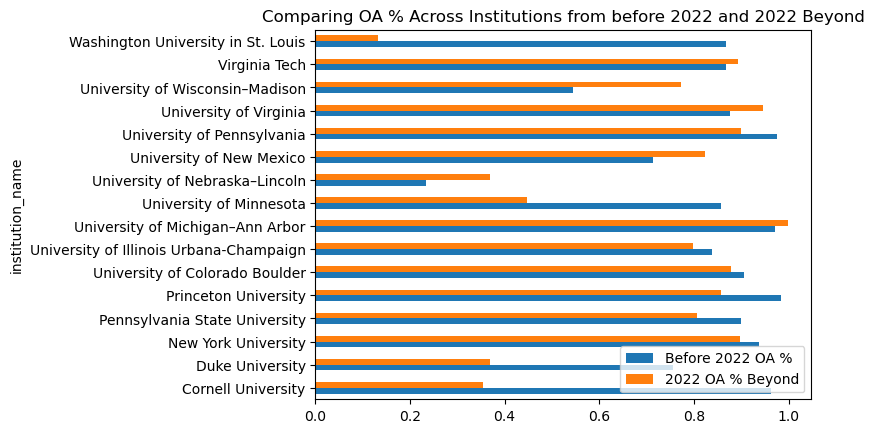

In [120]:
oa_df1 = counts('institution_name', 'is_oa', 'OA %', OA2021df).sort_values('institution_name', ascending=True)
oa_df2 = counts('institution_name', 'is_oa', 'OA %', OA2022df).sort_values('institution_name', ascending=True)
oa_df2 = oa_df2[oa_df2['institution_name'] != 'Michael J. Fox Foundation']

oa_df1 = oa_df1.rename(columns={'OA %': 'Before 2022 OA %'})
oa_df2 = oa_df2.rename(columns={'OA %': '2022 OA % Beyond'})

oa_df2 = oa_df2.reset_index(drop=True)
oa_df1 = pd.concat([oa_df1, oa_df2['2022 OA % Beyond']], axis=1)


# plotting sorted  by 2020 Diff 2018 on all there subjects (largest to smallest change)

oa_df_plot = oa_df1.plot(x="institution_name", y=['Before 2022 OA %', '2022 OA % Beyond'], kind="barh") 
oa_df_plot.set_title('Comparing OA % Across Institutions from before 2022 and 2022 Beyond')

oa_df_plot

In [121]:
# Read in RADs Data

rads_df = pd.read_csv('RADS_Datasets_MN.csv')
rads_df.head()


,institution,id,type,DOI,publisher,container_type,container_title,container_volume,container_firstPage,container_identifier,container_identifierType,container_lastPage,publicationYear,language,ris,bibtex,citeproc,schemaOrg,resourceType,resourceTypeGeneral,version,URL,metadataVersion,schemaVersion,source,isActive,state,...,downloadCount,referenceCount,citationCount,partCount,partOfCount,versionCount,versionOfCount,created,registered,published,updated,data_id,data_type,container_issue,group,member,reference-count,title,created.date-parts2,created.date-parts3,created.date-time,created.timestamp,name,doi,url,container.title,publisher_plus
0,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25.000Z,2011-08-26T16:27:25.000Z,2015.0,2020-07-28T04:29:43.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,10.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,16.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25Z,2011-08-26T16:27:25Z,NaN,2022-06-01T22:50:13Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,4.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,15.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08.000Z,2011-11-29T19:14:08.000Z,2016.0,2020-07-28T04:32:35.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,31.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08Z,2011-11-29T19:14:08Z,NaN,2022-06-01T22:29:52Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Minnesota,10.5061/dryad.rk5fp6n9,dois,10.5061/dryad.rk5fp6n9,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012,en,DATA,misc,dataset,Dataset,dataset,Dataset,1,http://datadryad.org/stash/dataset/doi:10.5061...,16.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,9.0,1.0,1.0,1.0,0.0,0.0,0.0,2012-01-05T21:18:31Z,2012-01-05T21:18:31Z,NaN,2022-05-31T22:46:15Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
len(rads_df)

4971

In [123]:
# Read in RADs Data
rads_df = rads_df[['institution', 'id', 'DOI', 'group', 'publisher', 'publicationYear', 'resourceTypeGeneral', 'resourceType', 'schemaOrg', 'citeproc', 'source', 'state']]

rads_df = rads_df.rename(columns={'resourceType': 'subjectType', 'publisher': 'Repository', 'group': 'index location'})
rads_df = rads_df.rename(columns={'publisher': 'Repository'})	
#rads_df = rads_df.replace({'Harvard Dataverse': 'Harvard dataverse'})
rads_df = rads_df.replace({'Zenodo': 'Zenodo (CERN European Organization for Nuclear Research)', 'figshare': 'Figshare', 'Affiliation - Datacite': 'datacite', 'Affiliation - CrossRef': 'crossref'})


rads_df = rads_df.replace('dataset', 'Dataset')
rads_df.head()

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [124]:
rads_df['index location'].value_counts()

index location
datacite        2580
crossref        1700
IR_publisher     691
Name: count, dtype: int64

In [125]:
rads_df['resourceTypeGeneral'].value_counts()

resourceTypeGeneral
Dataset    4971
Name: count, dtype: int64

In [126]:
rads_df['subjectType'].value_counts().head(20)

subjectType
Dataset                                         876
Dataset/Paleoecological Sample Data             210
Experimental Data                                79
Field Study Data                                 45
survey data                                      37
Simulation Data                                  31
Genomics Data                                    29
Programming Software Code                        24
Other Dataset                                    22
Specialized Mix                                  20
Experimental Data||Field Study Data              19
Field Study Data||Observational Data             19
Spatial Data                                     17
3D Imaging Data                                  16
Observational Data                               14
Programming Software Code||Simulation Data       12
Mass Spectrometry                                11
Experimental Data||Programming Software Code     10
Survey Data-Quantitative                          9


In [127]:
rads_df['citeproc'].value_counts().head(15)

citeproc
Dataset    2578
article       2
Name: count, dtype: int64

In [128]:
rads_df.head(15)

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
5,Minnesota,10.5061/dryad.3b2q4g1m,10.5061/dryad.3b2q4g1m,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
6,Minnesota,10.4232/1.11090,10.4232/1.11090,datacite,GESIS Data Archive,2012,Dataset,NaN,Dataset,Dataset,mds,findable
7,Minnesota,10.5061/dryad.d2c619hd,10.5061/dryad.d2c619hd,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
8,Minnesota,10.5061/dryad.nf91079h,10.5061/dryad.nf91079h,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
9,Minnesota,10.5061/dryad.5k3t47p0,10.5061/dryad.5k3t47p0,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [129]:
# Make a copy of df and Rads to look at faculty opinions
OAFac_df = df.copy()
Rads_Fac_df = rads_df.copy()

# Look before and up to 2022 as that's when RADS ends and OA starts
OAFac_df = OAFac_df[OAFac_df['publication_year'] <= 2022]

# subset only to UMN datasets
OAFac_df = OAFac_df[OAFac_df['institution_name'] == 'University of Minnesota']


In [130]:

MNFac_2022_repo_df = counts('Repository', 'is_oa', 'OA %', OAFac_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
#MNFac_repo_df = MNFac_repo_df.replace({'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature': 'Faculty Opinions Ltd'})
MNFac_2022_repo_df 

is_oa,Repository,False,True,OA %,Total
0,Faculty Opinions Ltd,1081.0,379.0,0.259589,1460.0
1,IUPAC Standards Online,220.0,26.0,0.105691,246.0
2,Default Digital Object Group,51.0,9.0,0.150000,60.0
3,OSTI OAI (U.S. Department of Energy Office of ...,27.0,0.0,0.000000,27.0
4,Zenodo (CERN European Organization for Nuclear...,8.0,196.0,0.960784,204.0
5,PMC,5.0,0.0,0.000000,5.0
6,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
7,Artifact Digital Object Group,2.0,0.0,0.000000,2.0
8,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
9,Figshare,0.0,12.0,1.000000,12.0


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Up To 2022 Repository Counts')

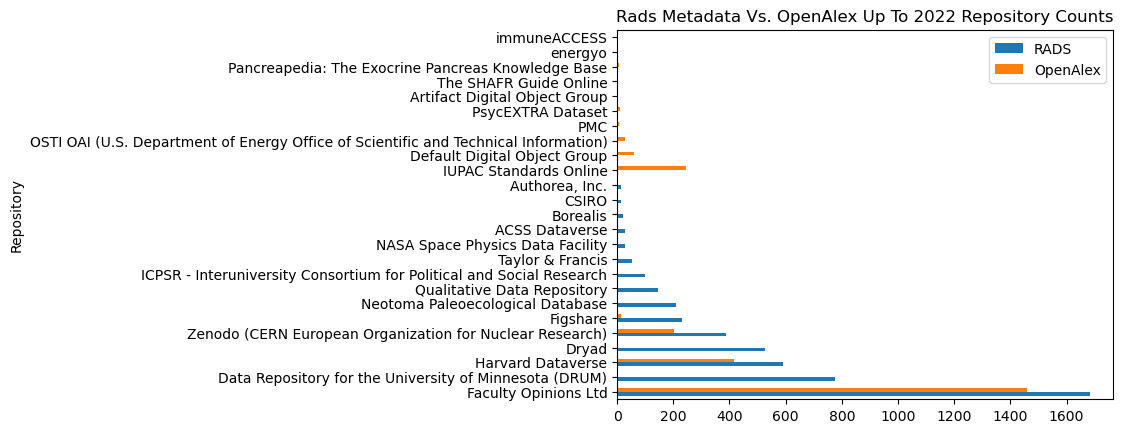

In [131]:
RadsFacDF = RadsCounts('Repository', 'resourceTypeGeneral', Rads_Fac_df, 'Dataset')

#merged.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh", stacked=True).set_title('Rads Metadata Vs. OpenAlex Pre 2022 Metadata')
OARadsFacDf = pd.merge(RadsFacDF.head(15), MNFac_2022_repo_df, on='Repository', how='outer')
OARadsFacDf = OARadsFacDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

OARadsFacDf.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Up To 2022 Repository Counts')

In [ ]:
# remove faculty opinions as it is not a dataset content
df = df[df['Repository'] != 'Faculty Opinions Ltd']
rads_df = rads_df[rads_df['Repository'] != 'Faculty Opinions Ltd']

# remove encode as it is not a dataset content
df = df[(df['Repository'] != 'ENCODE Datasets')]
rads_df = rads_df[rads_df['Repository'] != 'ENCODE Data Coordination Center']

# subset a new df to only UMN
MN_df = df[df['institution_name'] == 'University of Minnesota']

# subset two new dfs by year
#MN_2022df = MN_df[MN_df['publication_year'] >= 2022]
MN_2022_df = MN_df[MN_df['publication_year'] <= 2022]

1083

In [28]:
MN_repo_total = MN_df.groupby(['Repository'])['doi'].size().reset_index()
MN_repo_total = MN_repo_total.sort_values('doi',ascending=False)
MN_repo_total = MN_repo_total.rename(columns={ 'doi': 'DOI Count'})
MN_repo_total


,Repository,DOI Count
3,Harvard Dataverse,452
4,IUPAC Standards Online,246
10,Zenodo (CERN European Organization for Nuclear...,245
1,Default Digital Object Group,60
5,OSTI OAI (U.S. Department of Energy Office of ...,40
2,Figshare,12
8,PsycEXTRA Dataset,10
6,PMC,5
7,Pancreapedia: The Exocrine Pancreas Knowledge ...,5
0,Artifact Digital Object Group,4


Text(0.5, 1.0, 'OpenAlex Open Access Repository DOI Counts')

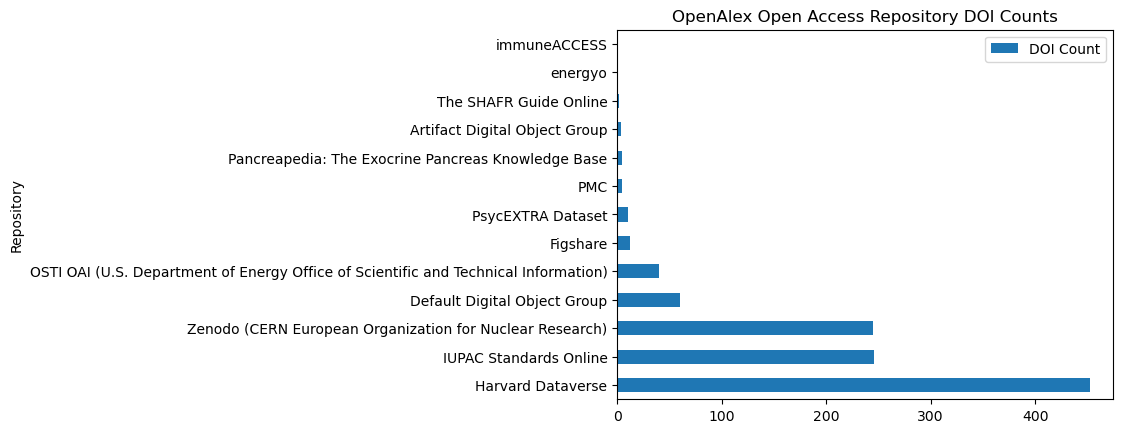

In [29]:
MN_repo_total.plot(x="Repository", y=['DOI Count'], kind="barh").set_title('OpenAlex Open Access Repository DOI Counts')

In [30]:
MN_2022_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2022_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_2022_repo_df 

is_oa,Repository,False,True,OA %,Total
0,IUPAC Standards Online,220.0,26.0,0.105691,246.0
1,Default Digital Object Group,51.0,9.0,0.150000,60.0
2,OSTI OAI (U.S. Department of Energy Office of ...,27.0,0.0,0.000000,27.0
3,Zenodo (CERN European Organization for Nuclear...,8.0,196.0,0.960784,204.0
4,PMC,5.0,0.0,0.000000,5.0
5,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
6,Artifact Digital Object Group,2.0,0.0,0.000000,2.0
7,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
8,Figshare,0.0,12.0,1.000000,12.0
9,Harvard Dataverse,0.0,416.0,1.000000,416.0


Text(0.5, 1.0, 'Rads Vs. OpenAlex Repository Counts Up To 2022 Without Faculty Opinions')

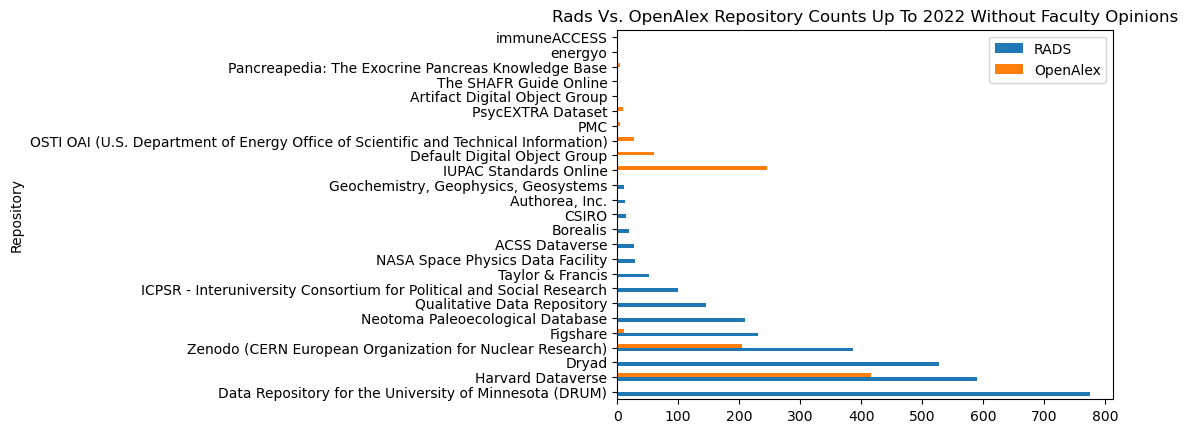

In [31]:
RadsRepoDF = RadsCounts('Repository', 'resourceTypeGeneral', rads_df, 'Dataset')

#merged.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh", stacked=True).set_title('Rads Metadata Vs. OpenAlex Pre 2022 Metadata')
OARadsRepoDf = pd.merge(RadsRepoDF.head(15), MN_2022_repo_df, on='Repository', how='outer')
OARadsRepoDf = OARadsRepoDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

OARadsRepoDf.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Vs. OpenAlex Repository Counts Up To 2022 Without Faculty Opinions')

In [32]:
len(OAFac_df), len(Rads_Fac_df), len(MN_2022_df), len(rads_df)

(2451, 4971, 991, 3289)

In [33]:
FacData = {'Repository': ['RADS', 'OpenAlex'], 'Includes Faculty Opinions': pd.Series([len(Rads_Fac_df), len(OAFac_df)]), 'No Faculty Opinions': pd.Series([len(rads_df), len(MN_2022_df)])}
FacOpinionsCounts_df = pd.DataFrame(data=FacData, index=[0, 1])
FacOpinionsCounts_df

,Repository,Includes Faculty Opinions,No Faculty Opinions
0,RADS,4971,3289
1,OpenAlex,2451,991


Text(0.5, 1.0, 'Rads Vs. OpenAlex Faculty Opinions Dataset Count')

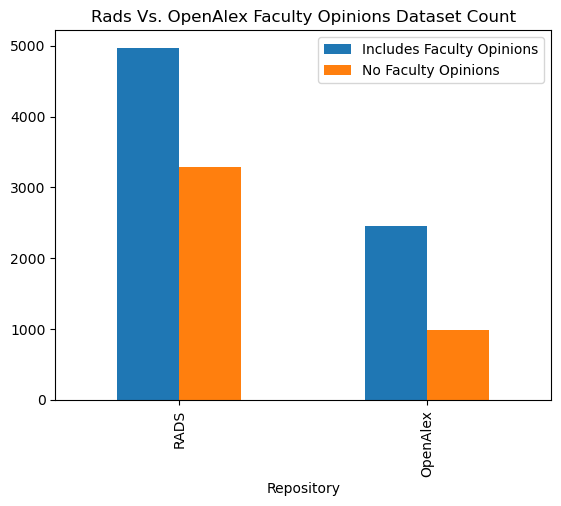

In [34]:
FacOpinionsCounts_df.plot(x="Repository", y=["Includes Faculty Opinions", "No Faculty Opinions"], kind="bar").set_title('Rads Vs. OpenAlex Faculty Opinions Dataset Count')

In [35]:
# No FAculty Opinions subject type in RADS data
FacOpinionsSubjects_df = multiple_counts('Repository', 'field_name', 'is_oa', 'OA %', OAFac_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
FacOpinionsSubjects_df.head(20)

is_oa,Repository,field_name,False,True,OA %,Total
0,Faculty Opinions Ltd,"Biochemistry, Genetics and Molecular Biology",383.0,171.0,0.308664,554.0
1,Faculty Opinions Ltd,Medicine,332.0,106.0,0.242009,438.0
2,IUPAC Standards Online,Computer Science,109.0,0.0,0.000000,109.0
3,Faculty Opinions Ltd,Agricultural and Biological Sciences,82.0,25.0,0.233645,107.0
4,Faculty Opinions Ltd,Immunology and Microbiology,61.0,25.0,0.290698,86.0
5,IUPAC Standards Online,"Pharmacology, Toxicology and Pharmaceutics",34.0,0.0,0.000000,34.0
6,IUPAC Standards Online,"Biochemistry, Genetics and Molecular Biology",34.0,1.0,0.028571,35.0
7,Faculty Opinions Ltd,Environmental Science,28.0,9.0,0.243243,37.0
8,Faculty Opinions Ltd,Chemistry,27.0,3.0,0.100000,30.0
9,Faculty Opinions Ltd,Engineering,26.0,9.0,0.257143,35.0


In [36]:
Rads_Fac_df.head()

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [37]:
#source = RadsCounts('Repository', 'source', rads_df, 'source')
Rads_Fac_df.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)

,Repository,index location,count
0,Faculty Opinions Ltd,crossref,1682
1,Data Repository for the University of Minnesot...,IR_publisher,691
2,Harvard Dataverse,datacite,590
3,Dryad,datacite,528
4,Zenodo (CERN European Organization for Nuclear...,datacite,387
5,Figshare,datacite,231
6,Neotoma Paleoecological Database,datacite,210
7,Qualitative Data Repository,datacite,145
8,ICPSR - Interuniversity Consortium for Politic...,datacite,99
9,Data Repository for the University of Minnesot...,datacite,83


In [38]:
# Make a subset of the data that is only faculty opinions
FacOnlyOA = OAFac_df[OAFac_df['Repository'] == 'Faculty Opinions Ltd']
FacOnlyRads =  Rads_Fac_df[Rads_Fac_df['Repository'] == 'Faculty Opinions Ltd']

In [39]:
FacOnlyOAIndex = multiple_counts('Repository', 'index location', 'is_oa', 'OA %', FacOnlyOA).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)

#FacOnlyOAIndex = FacOnlyOA.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
FacOnlyOAIndex = FacOnlyOAIndex.rename(columns={"count": "OpenAlex"})

FacOnlyOAIndex


is_oa,Repository,index location,False,True,OA %,Total
0,Faculty Opinions Ltd,crossref,1081,379,0.259589,1460


In [40]:
df['index location'].value_counts()

index location
datacite    49902
crossref     2804
arxiv          13
Name: count, dtype: int64

In [41]:
FacOnlyRadsIndex = FacOnlyRads.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
FacOnlyRadsIndex = FacOnlyRadsIndex.rename(columns={"count": "RADS"})

FacOnlyRadsIndex

,Repository,index location,RADS
0,Faculty Opinions Ltd,crossref,1682


Text(0.5, 1.0, 'OpenAlex Vs. RADS Faculty Opinion Index Location Counts')

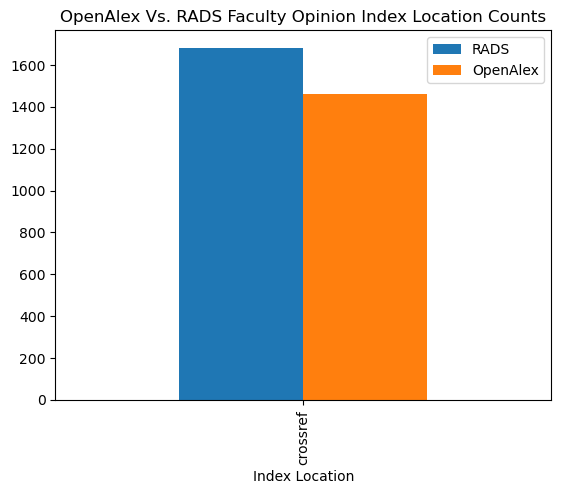

In [42]:
OARadsIndexDf = pd.merge(FacOnlyOAIndex, FacOnlyRadsIndex, on='Repository', how='inner')
OARadsIndexDf = OARadsIndexDf.rename(columns={"count_x": "RADS",  "Total": "OpenAlex", "index location_x": "Index Location"})

OARadsIndexDf.plot(x="Index Location", y=["RADS", "OpenAlex"], kind="bar").set_title('OpenAlex Vs. RADS Faculty Opinion Index Location Counts')

In [43]:
OA_FacYear_df = multiple_counts('Repository', 'publication_year', 'is_oa', 'OA %', FacOnlyOA).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
OA_FacYear_df = OA_FacYear_df.sort_values(by='Total', ascending=False).reset_index(drop=True)
OA_FacYear_df = OA_FacYear_df[['Repository', 'publication_year', 'Total']].sort_values(by='publication_year', ascending=False).reset_index(drop=True)
OA_FacYear_df

is_oa,Repository,publication_year,Total
0,Faculty Opinions Ltd,2022,42.0
1,Faculty Opinions Ltd,2021,51.0
2,Faculty Opinions Ltd,2020,123.0
3,Faculty Opinions Ltd,2019,83.0
4,Faculty Opinions Ltd,2018,50.0
5,Faculty Opinions Ltd,2017,110.0
6,Faculty Opinions Ltd,2016,105.0
7,Faculty Opinions Ltd,2015,40.0
8,Faculty Opinions Ltd,2014,93.0
9,Faculty Opinions Ltd,2013,103.0


In [44]:
Rads_FacYear_df = FacOnlyRads.groupby(['Repository'])['publicationYear'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
Rads_FacYear_df = Rads_FacYear_df.rename(columns={"count": "RADS",  "Total": "OpenAlex", "publicationYear":"publication_year"})
Rads_FacYear_df = Rads_FacYear_df.sort_values(by='publication_year', ascending=False).reset_index(drop=True)


Rads_FacYear_df

,Repository,publication_year,RADS
0,Faculty Opinions Ltd,2022,15
1,Faculty Opinions Ltd,2021,69
2,Faculty Opinions Ltd,2020,264
3,Faculty Opinions Ltd,2019,122
4,Faculty Opinions Ltd,2018,63
5,Faculty Opinions Ltd,2017,111
6,Faculty Opinions Ltd,2016,120
7,Faculty Opinions Ltd,2015,46
8,Faculty Opinions Ltd,2014,93
9,Faculty Opinions Ltd,2013,98


In [45]:
FacYear_df = pd.merge(OA_FacYear_df, Rads_FacYear_df, on='publication_year', how='outer')
FacYear_df = FacYear_df.rename(columns={"Repository_x": "Repository",  "Total": "OpenAlex"})

FacYear_df = FacYear_df[['Repository', 'publication_year', 'RADS', 'OpenAlex']]

FacYear_df['Repository'] = FacYear_df['Repository'].fillna('Faculty Opinions Ltd')

FacYear_df = FacYear_df.sort_values(by=['publication_year'], ascending=False)
FacYear_df

,Repository,publication_year,RADS,OpenAlex
0,Faculty Opinions Ltd,2022,15.0,42.0
1,Faculty Opinions Ltd,2021,69.0,51.0
2,Faculty Opinions Ltd,2020,264.0,123.0
3,Faculty Opinions Ltd,2019,122.0,83.0
4,Faculty Opinions Ltd,2018,63.0,50.0
5,Faculty Opinions Ltd,2017,111.0,110.0
6,Faculty Opinions Ltd,2016,120.0,105.0
7,Faculty Opinions Ltd,2015,46.0,40.0
8,Faculty Opinions Ltd,2014,93.0,93.0
9,Faculty Opinions Ltd,2013,98.0,103.0


Text(0.5, 1.0, 'Faculty Opinions Publication Year Counts')

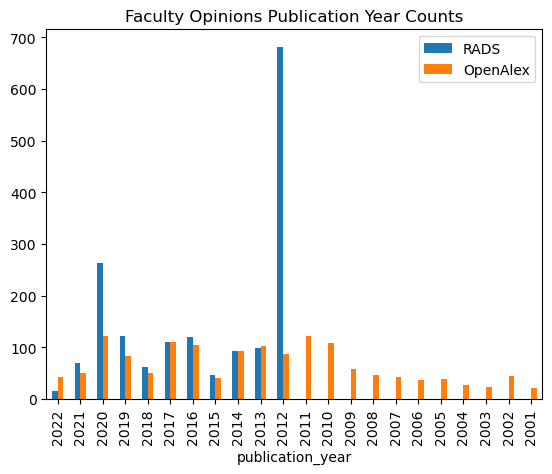

In [46]:
FacYear_df.plot(x="publication_year", y=["RADS", "OpenAlex"], kind="bar").set_title('Faculty Opinions Publication Year Counts')


# Removing Faculty Opinions

In [47]:
RadsYear_df = RadsCounts('publicationYear', 'resourceTypeGeneral', rads_df, 'publicationYear')
RadsYear_df = RadsYear_df.rename(columns={"Dataset": "RADS",  "publicationYear": "publication_year"})

RadsYear_df

#mn_year_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
#mn_year_df = mn_year_df.rename(columns={"Total": "OpenAlex"})

resourceTypeGeneral,publication_year,RADS
0,2022,655
1,2021,448
2,2020,525
3,2019,383
4,2018,385
5,2017,579
6,2016,113
7,2015,78
8,2014,39
9,2013,51


In [48]:

OAYear_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
OAYear_df = OAYear_df.rename(columns={"Total": "OpenAlex"})
OAYear_df

is_oa,institution_name,publication_year,False,True,OA %,OpenAlex
19,University of Minnesota,2024,16.0,5.0,0.238095,21.0
18,University of Minnesota,2023,14.0,57.0,0.802817,71.0
17,University of Minnesota,2022,229.0,148.0,0.392573,377.0
16,University of Minnesota,2021,0.0,53.0,1.000000,53.0
15,University of Minnesota,2020,10.0,144.0,0.935065,154.0
14,University of Minnesota,2019,8.0,104.0,0.928571,112.0
13,University of Minnesota,2018,5.0,105.0,0.954545,110.0
12,University of Minnesota,2017,6.0,8.0,0.571429,14.0
11,University of Minnesota,2016,10.0,29.0,0.743590,39.0
10,University of Minnesota,2015,0.0,4.0,1.000000,4.0


Text(0.5, 1.0, 'Rads Vs. OpenAlex Total Publication Counts by Year')

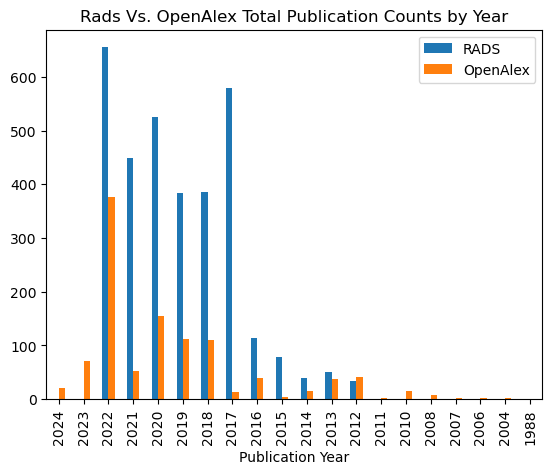

In [49]:

OARadsYearsDf = pd.merge(OAYear_df, RadsYear_df, on='publication_year', how='outer')
OARadsYearsDf = OARadsYearsDf.rename(columns={"publication_year": "Publication Year"})
OARadsYearsDf.plot(x="Publication Year", y=["RADS", "OpenAlex"], kind="bar").set_title('Rads Vs. OpenAlex Total Publication Counts by Year')

In [50]:
RadsAllIndexDf = rads_df.groupby(['index location'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
RadsAllIndexDf = RadsAllIndexDf.rename(columns={"count": "RADS"})
RadsAllIndexDf = RadsAllIndexDf[['index location', 'RADS']]
RadsAllIndexDf

,index location,RADS
0,datacite,2580
1,IR_publisher,691
2,crossref,18


In [51]:
OAAllIndexDf = MN_df.groupby(['index location'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
OAAllIndexDf = OAAllIndexDf.rename(columns={"count": "OpenAlex"})
OAAllIndexDf = OAAllIndexDf[['index location', 'OpenAlex']]
OAAllIndexDf

,index location,OpenAlex
0,datacite,709
1,crossref,329


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Index Location Counts')

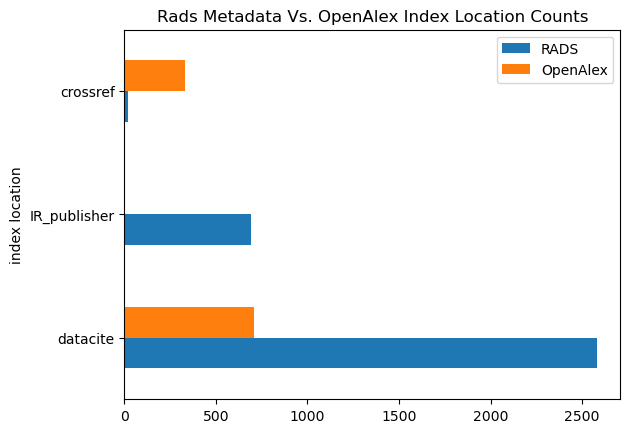

In [52]:
OARadsIndexDf = pd.merge(RadsAllIndexDf, OAAllIndexDf, on='index location', how='outer')
OARadsIndexDf = OARadsIndexDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})
OARadsIndexDf 

OARadsIndexDf.plot(x="index location", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Index Location Counts')


In [53]:
rads_subject_df = rads_df[rads_df['subjectType'] != 'Dataset']


In [54]:
RadsAllSubjectDf = rads_subject_df.groupby(['subjectType'])['subjectType'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
RadsAllSubjectDf = RadsAllSubjectDf.rename(columns={"count": "RADS"})
RadsAllSubjectDf = RadsAllSubjectDf[['subjectType', 'RADS']]
RadsAllSubjectDf

,subjectType,RADS
0,Dataset/Paleoecological Sample Data,210
1,Experimental Data,79
2,Field Study Data,45
3,survey data,37
4,Simulation Data,31
5,Genomics Data,29
6,Programming Software Code,24
7,Other Dataset,22
8,Specialized Mix,20
9,Field Study Data||Observational Data,19


In [55]:
OAAllSubFieldDf = MN_df.groupby(['subfield_name'])['subfield_name'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
OAAllSubFieldDf = OAAllSubFieldDf.rename(columns={"count": "OpenAlex", "subfield_name": 'subjectType'})
OAAllSubFieldDf = OAAllSubFieldDf[['subjectType', 'OpenAlex']]
OAAllSubFieldDf

,subjectType,OpenAlex
0,Computational Theory and Mathematics,111
1,Astronomy and Astrophysics,59
2,Sociology and Political Science,41
3,Molecular Biology,40
4,Political Science and International Relations,33
5,Spectroscopy,30
6,Pharmacology,29
7,Atmospheric Science,20
8,"Radiology, Nuclear Medicine and Imaging",19
9,Plant Science,19


In [56]:
OARadsSubjectDf = pd.merge(RadsAllSubjectDf, OAAllSubFieldDf, on='subjectType', how='outer')
OARadsSubjectDf = OARadsSubjectDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})
OARadsSubjectDf 

#OARadsSubjectDf.plot(x="subjectType", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Index Location Counts')


,subjectType,RADS,OpenAlex
0,Dataset/Paleoecological Sample Data,210.0,NaN
1,Experimental Data,79.0,NaN
2,Field Study Data,45.0,NaN
3,survey data,37.0,NaN
4,Simulation Data,31.0,NaN
5,Genomics Data,29.0,NaN
6,Programming Software Code,24.0,NaN
7,Other Dataset,22.0,NaN
8,Specialized Mix,20.0,NaN
9,Field Study Data||Observational Data,19.0,NaN


In [57]:
MN_repo_df = counts('Repository', 'is_oa', 'OA %', MN_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_repo_df = MN_repo_df[['Repository', False, True]]
MN_repo_df = MN_repo_df.rename(columns={False: 'Not OA', True: 'Is OA'})

MN_repo_df

is_oa,Repository,Not OA,Is OA
0,IUPAC Standards Online,220.0,26.0
1,Default Digital Object Group,51.0,9.0
2,OSTI OAI (U.S. Department of Energy Office of ...,40.0,0.0
3,Zenodo (CERN European Organization for Nuclear...,23.0,222.0
4,PMC,5.0,0.0
5,Artifact Digital Object Group,4.0,0.0
6,PsycEXTRA Dataset,2.0,8.0
7,The SHAFR Guide Online,2.0,0.0
8,Figshare,0.0,12.0
9,Harvard Dataverse,0.0,452.0


Text(0.5, 1.0, 'OpenAlex Open Access by Repository')

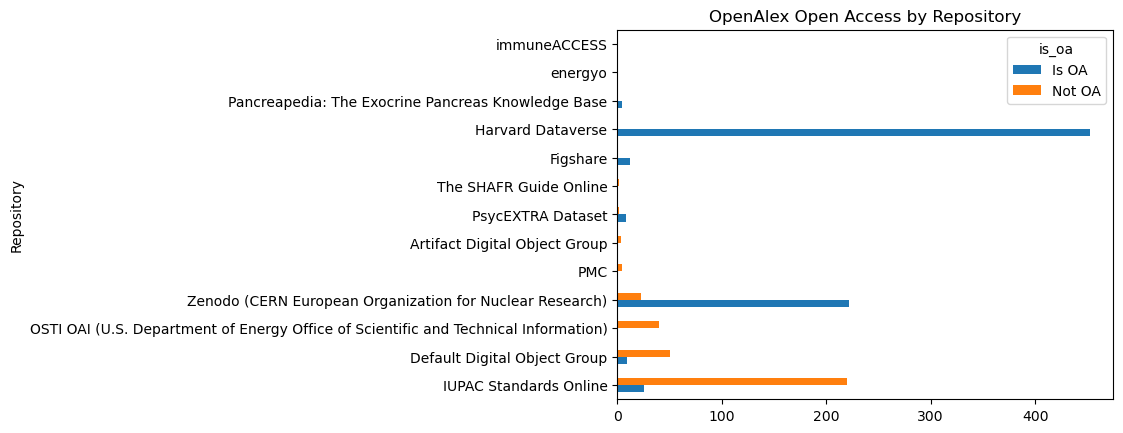

In [58]:
MN_repo_df.plot(x="Repository", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Repository')

In [59]:
MN_field_df = counts('field_name', 'is_oa', 'OA %', MN_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_field_df = MN_field_df[['field_name', False, True]]
MN_field_df = MN_field_df.rename(columns={False: 'Not OA', True: 'Is OA', 'field_name': 'Field Name'})

MN_field_df

is_oa,Field Name,Not OA,Is OA
0,Computer Science,114.0,32.0
1,"Biochemistry, Genetics and Molecular Biology",45.0,22.0
2,Environmental Science,36.0,31.0
3,"Pharmacology, Toxicology and Pharmaceutics",34.0,0.0
4,Medicine,24.0,30.0
5,Engineering,20.0,54.0
6,Chemistry,12.0,34.0
7,Agricultural and Biological Sciences,9.0,24.0
8,Physics and Astronomy,6.0,77.0
9,Earth and Planetary Sciences,4.0,37.0


Text(0.5, 1.0, 'OpenAlex Open Access by Field')

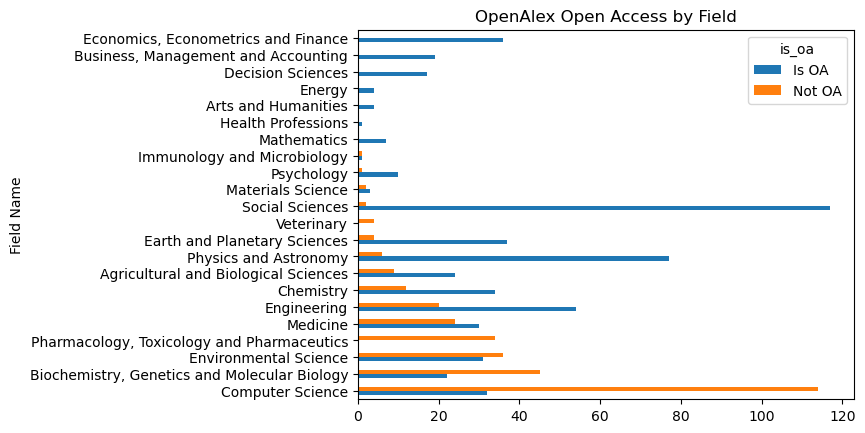

In [60]:
MN_field_df.plot(x="Field Name", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Field')

In [61]:
MN_subfield_df = multiple_counts('subfield_name', 'Repository', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(25)
MN_subfield_df['Total'] = MN_subfield_df[True] + MN_subfield_df[False]

MN_subfield_df

is_oa,subfield_name,Repository,False,True,OA %,Total
0,Computational Theory and Mathematics,IUPAC Standards Online,109.0,0.0,0.000000,109.0
1,Pharmacology,IUPAC Standards Online,29.0,0.0,0.000000,29.0
2,Molecular Biology,IUPAC Standards Online,18.0,1.0,0.052632,19.0
3,Physiology,IUPAC Standards Online,11.0,2.0,0.153846,13.0
4,Environmental Engineering,OSTI OAI (U.S. Department of Energy Office of ...,11.0,0.0,0.000000,11.0
5,Computational Mechanics,Default Digital Object Group,8.0,0.0,0.000000,8.0
6,Physical and Theoretical Chemistry,IUPAC Standards Online,8.0,1.0,0.111111,9.0
7,Water Science and Technology,OSTI OAI (U.S. Department of Energy Office of ...,7.0,0.0,0.000000,7.0
8,Global and Planetary Change,OSTI OAI (U.S. Department of Energy Office of ...,6.0,0.0,0.000000,6.0
9,Food Science,PMC,5.0,0.0,0.000000,5.0


In [62]:
counts('domain_name', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(25)

is_oa,domain_name,False,True,OA %,Total
0,Physical Sciences,194,279,0.589852,473
1,Life Sciences,89,47,0.345588,136
2,Health Sciences,28,31,0.525424,59
3,Social Sciences,3,203,0.985437,206


In [63]:
MN_departments_df = multiple_counts('raw_affiliation_strings', 'Repository', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(33)
MN_departments_df = MN_departments_df[['raw_affiliation_strings', False, True]]
MN_departments_df = MN_departments_df.rename(columns={False: 'Not OA', True: 'Is OA', 'raw_affiliation_strings': 'Department'}).head(25)
MN_departments_df['Department'] = MN_departments_df['Department'].str[0:50]
MN_departments_df

is_oa,Department,Not OA,Is OA
0,"Department of Medicinal Chemistry, University ...",214.0,0.0
1,Department of Aerospace Engineering and Mechan...,28.0,0.0
2,University of Minnesota - St. Paul,21.0,0.0
3,"University of Minnesota, Saint Paul, MN (Unite...",11.0,0.0
4,"Univ. of Minnesota, Minneapolis, MN (United St...",7.0,0.0
5,"University of Minnesota, Minneapolis 14, Minn....",6.0,25.0
6,"University of Minnesota, College of Veterinary...",4.0,0.0
7,"Department of Ecology, Evolution and Behavior,...",4.0,2.0
8,"Department of Chemistry, University of Minneso...",4.0,0.0
9,"Department of Mechanical Engineering, Universi...",4.0,0.0


Text(0.5, 1.0, 'OpenAlex Open Access by Department')

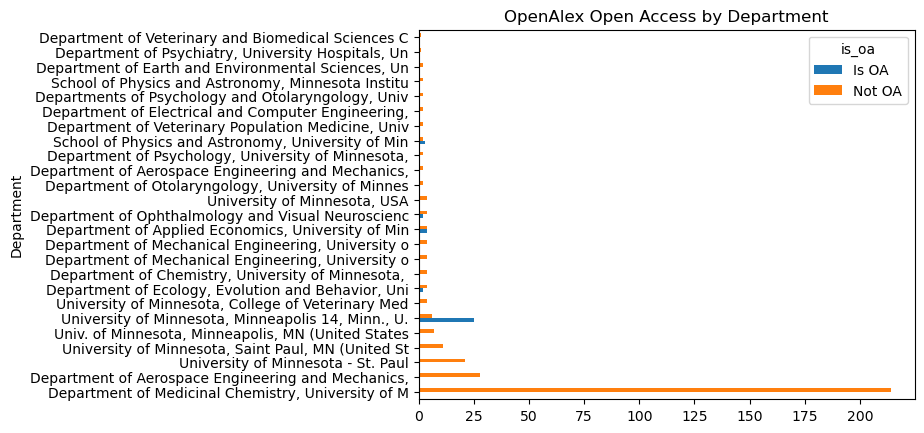

In [64]:
MN_departments_df.plot(x="Department", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Department')

In [65]:
MN_Year_df = counts('publication_year', 'is_oa', 'OA %', MN_df).sort_values(by='publication_year', ascending=False).reset_index(drop=True)
MN_Year_df = MN_Year_df[['publication_year', False, True]]
MN_Year_df = MN_Year_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year'})

MN_Year_df

is_oa,Publication Year,Not OA,Is OA
0,2024,16.0,5.0
1,2023,14.0,57.0
2,2022,229.0,148.0
3,2021,0.0,53.0
4,2020,10.0,144.0
5,2019,8.0,104.0
6,2018,5.0,105.0
7,2017,6.0,8.0
8,2016,10.0,29.0
9,2015,0.0,4.0


Text(0.5, 1.0, 'OpenAlex Open Access by Publication Year')

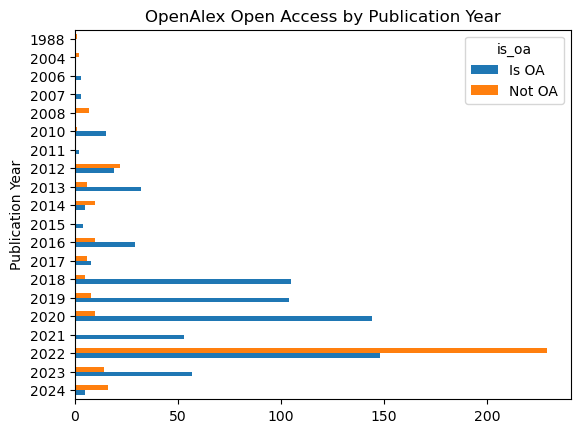

In [66]:
MN_Year_df.plot(x="Publication Year", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Publication Year')

In [67]:
MNAuthor_df = counts('author_name','is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True)
MNAuthor_df = MNAuthor_df[['author_name', False, True]]
MNAuthor_df = MNAuthor_df.rename(columns={False: 'Not OA', True: 'Is OA',  'author_name': 'Author'})
MNAuthor_df['Author Not OA%'] = MNAuthor_df['Not OA'] / MNAuthor_df['Not OA'].sum()
MNAuthor_df = MNAuthor_df.head(10)
MNAuthor_df

is_oa,Author,Not OA,Is OA,Author Not OA%
0,Phillip Portoghese,214.0,0.0,0.616715
1,Ellen K. Longmire,14.0,0.0,0.040346
2,Ankur Bordoloi,11.0,0.0,0.031700
3,E. B. Sandell,6.0,25.0,0.017291
4,Timothy J. Griffis,4.0,2.0,0.011527
5,Sharey Deep Guleria,4.0,0.0,0.011527
6,Matt Erickson,4.0,0.0,0.011527
7,Cody Winker,3.0,0.0,0.008646
8,Zachary W. Buell,3.0,0.0,0.008646
9,Alexandra R. Armstrong,2.0,0.0,0.005764


Text(0.5, 1.0, 'OpenAlex Open Access by Author')

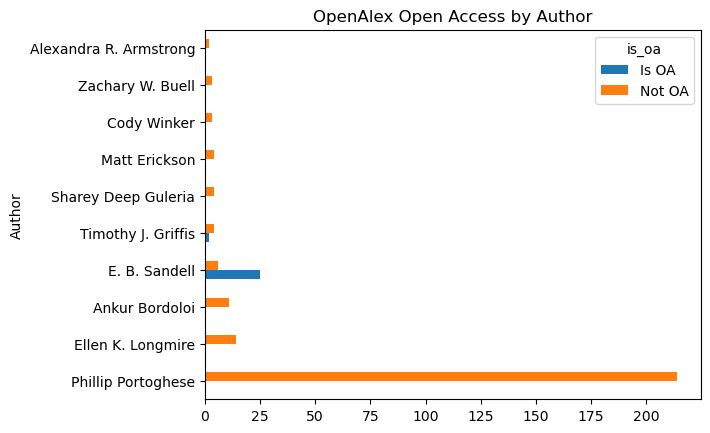

In [68]:
MNAuthor_plot = MNAuthor_df.plot(x="Author", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Author')

MNAuthor_plot

In [69]:
MN_Author_Context_df = MN_df.groupby(['author_name', 'field_name', 'publication_year'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_Context_df = MN_Author_Context_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_Context_df = MN_Author_Context_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author', 'field_name': 'Field Name'})
MN_Author_Context_df['% Of Not Open Access'] = MN_Author_Context_df['Not OA'] / MN_Author_Context_df['Not OA'].sum()
MN_Author_Context_df = MN_Author_Context_df.head(10)
MN_Author_Context_df #, 'field_name'

is_oa,Author,Field Name,Publication Year,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,Computer Science,2022,109.0,0.0,0.347134
1,Phillip Portoghese,"Pharmacology, Toxicology and Pharmaceutics",2022,34.0,0.0,0.108280
2,Phillip Portoghese,"Biochemistry, Genetics and Molecular Biology",2022,33.0,0.0,0.105096
3,Phillip Portoghese,Medicine,2022,20.0,0.0,0.063694
4,Phillip Portoghese,Chemistry,2022,11.0,0.0,0.035032
5,Phillip Portoghese,Environmental Science,2022,5.0,0.0,0.015924
6,Sharey Deep Guleria,Engineering,2022,4.0,0.0,0.012739
7,Ellen K. Longmire,Engineering,2012,4.0,0.0,0.012739
8,Ankur Bordoloi,Engineering,2012,4.0,0.0,0.012739
9,A. H. Sulaiman,Physics and Astronomy,2023,2.0,2.0,0.006369


In [70]:
author_info_df = MN_df.groupby(['author_name'])['index location'].value_counts().reset_index().sort_values(by=['count'], ascending=False)
author_info_df = author_info_df.fillna(0).reset_index(drop=True)
author_info_df.head(25)

,author_name,index location,count
0,Phillip Portoghese,crossref,214
1,Herbert M. Kritzer,datacite,47
2,Jason Kerwin,datacite,34
3,Thomas Hasenzagl,datacite,34
4,E. B. Sandell,crossref,31
5,James R. Hollyer,datacite,24
6,Cosette Creamer,datacite,23
7,L. Fortson,datacite,20
8,David Samuels,datacite,20
9,Ellen K. Longmire,crossref,14


In [71]:
author_infoRepo_df = MN_df.groupby(['author_name'])['Repository'].value_counts().reset_index().sort_values(by=['count'], ascending=False)
author_infoRepo_df = author_infoRepo_df.fillna(0).reset_index(drop=True)
author_infoRepo_df.head(25)

,author_name,Repository,count
0,Phillip Portoghese,IUPAC Standards Online,214
1,Herbert M. Kritzer,Harvard Dataverse,47
2,Thomas Hasenzagl,Harvard Dataverse,34
3,Jason Kerwin,Harvard Dataverse,34
4,E. B. Sandell,IUPAC Standards Online,31
5,James R. Hollyer,Harvard Dataverse,24
6,Cosette Creamer,Harvard Dataverse,23
7,L. Fortson,Zenodo (CERN European Organization for Nuclear...,20
8,David Samuels,Harvard Dataverse,20
9,Ellen K. Longmire,Default Digital Object Group,14


In [72]:
author_infopos_df = MN_df.groupby(['author_name'])['author_position'].value_counts().reset_index().sort_values(by=['count'], ascending=False)
author_infopos_df = author_infopos_df.fillna(0).reset_index(drop=True)
author_infopos_df.head(25)

,author_name,author_position,count
0,Phillip Portoghese,middle,214
1,Herbert M. Kritzer,first,47
2,Thomas Hasenzagl,first,34
3,E. B. Sandell,first,31
4,Jason Kerwin,first,27
5,Cosette Creamer,first,23
6,James R. Hollyer,middle,22
7,L. Fortson,middle,20
8,Cory L. Struthers,first,13
9,David Samuels,last,12


In [73]:
author_infocollab_df = MN_df.groupby(['title'])['author_name'].value_counts().reset_index().sort_values(by=['count'], ascending=False)
author_infocollab_df = author_infocollab_df.fillna(0).reset_index(drop=True)
author_infocollab_df.head(25)

,title,author_name,count
0,VTSCat: The VERITAS Catalog of Gamma-Ray Obser...,L. Fortson,17
1,SNAPP Flow Impacts Literature Review Datasets,Kate A. Brauman,5
2,Mapping the planet's critical areas for biodiv...,Justin A. Johnson,4
3,DLPS_v1_10-2018.tab,Cory L. Struthers,4
4,Analysis of Whistler-Mode and Z-Mode Emission ...,S. S. Elliott,4
5,Mapping the planet's critical areas for biodiv...,Stephen Polasky,4
6,QTL mapping of human retina DNA methylation id...,Deborah A. Ferrington,3
7,"Data for manuscript, ""An optimized workflow fo...",Alan Mickelson,3
8,Dynamics in a stellar convective layer and at ...,Huaqing Mao,3
9,"Data for manuscript, ""An optimized workflow fo...",Danielle O. Weise,3


In [74]:
author_inforetract_df = MN_df.groupby(['author_name'])['retracted'].value_counts().reset_index().sort_values(by=['count'], ascending=False)
author_inforetract_df = author_inforetract_df.fillna(0).reset_index(drop=True)
author_inforetract_df = author_inforetract_df[author_inforetract_df['retracted'] == True] 
author_inforetract_df.head(25)

,author_name,retracted,count


In [75]:
MN_Author_Index_df = MN_df.groupby(['author_name', 'index location'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_Index_df = MN_Author_Index_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_Index_df = MN_Author_Index_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author'})
MN_Author_Index_df['% Of Not Open Access'] = MN_Author_Index_df['Not OA'] / MN_Author_Index_df['Not OA'].sum()
MN_Author_Index_df = MN_Author_Index_df.head(25)
MN_Author_Index_df #, 'field_name'

is_oa,Author,index location,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,crossref,214.0,0.0,0.708609
1,Ellen K. Longmire,crossref,14.0,0.0,0.046358
2,Ankur Bordoloi,crossref,11.0,0.0,0.036424
3,E. B. Sandell,crossref,6.0,25.0,0.019868
4,Sharey Deep Guleria,crossref,4.0,0.0,0.013245
5,Heather A. Kreft,crossref,2.0,0.0,0.006623
6,Mihailo R. Jovanović,crossref,2.0,0.0,0.006623
7,Michael Travisano,datacite,2.0,0.0,0.006623
8,Matthew Stegmeir,crossref,2.0,0.0,0.006623
9,Stephen Polasky,datacite,2.0,2.0,0.006623


In [76]:
MN_Author_Repo_df = MN_df.groupby(['author_name', 'Repository'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_Repo_df = MN_Author_Repo_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_Repo_df = MN_Author_Repo_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author'})
MN_Author_Repo_df['% Of Not Open Access'] = MN_Author_Repo_df['Not OA'] / MN_Author_Repo_df['Not OA'].sum()
MN_Author_Repo_df = MN_Author_Repo_df.head(25)
MN_Author_Repo_df #, 'field_name'

is_oa,Author,Repository,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,IUPAC Standards Online,214.0,0.0,0.616715
1,Ellen K. Longmire,Default Digital Object Group,14.0,0.0,0.040346
2,Ankur Bordoloi,Default Digital Object Group,11.0,0.0,0.031700
3,E. B. Sandell,IUPAC Standards Online,6.0,25.0,0.017291
4,Timothy J. Griffis,OSTI OAI (U.S. Department of Energy Office of ...,4.0,0.0,0.011527
5,Sharey Deep Guleria,Default Digital Object Group,4.0,0.0,0.011527
6,Matt Erickson,OSTI OAI (U.S. Department of Energy Office of ...,4.0,0.0,0.011527
7,Cody Winker,OSTI OAI (U.S. Department of Energy Office of ...,3.0,0.0,0.008646
8,Zachary W. Buell,OSTI OAI (U.S. Department of Energy Office of ...,3.0,0.0,0.008646
9,Kuen-Bang Hou,Artifact Digital Object Group,2.0,0.0,0.005764


In [77]:
MN_Author_Orcid_df = MN_df.groupby(['author_name', 'orcid'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_Orcid_df = MN_Author_Orcid_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_Orcid_df = MN_Author_Orcid_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author'})
MN_Author_Orcid_df['% Of Not Open Access'] = MN_Author_Orcid_df['Not OA'] / MN_Author_Orcid_df['Not OA'].sum()
MN_Author_Orcid_df = MN_Author_Orcid_df.head(25)
MN_Author_Orcid_df #, 'field_name'

is_oa,Author,orcid,Not OA,Is OA,% Of Not Open Access
0,Ellen K. Longmire,https://orcid.org/0000-0002-3479-3358,14.0,0.0,0.142857
1,Ankur Bordoloi,https://orcid.org/0000-0001-8314-0065,11.0,0.0,0.112245
2,Matt Erickson,https://orcid.org/0000-0002-2465-3060,4.0,0.0,0.040816
3,Sharey Deep Guleria,https://orcid.org/0000-0002-1789-3023,4.0,0.0,0.040816
4,Timothy J. Griffis,https://orcid.org/0000-0002-2111-5144,4.0,2.0,0.040816
5,Cody Winker,https://orcid.org/0000-0002-8944-1587,3.0,0.0,0.030612
6,Ferenc Tóth,https://orcid.org/0000-0002-6615-389X,2.0,0.0,0.020408
7,Michael Travisano,https://orcid.org/0000-0001-8168-0842,2.0,0.0,0.020408
8,Sandra R. Montezuma,https://orcid.org/0000-0003-3731-8082,2.0,1.0,0.020408
9,Kuen-Bang Hou,https://orcid.org/0000-0002-2310-3673,2.0,0.0,0.020408


In [78]:
MN_Author_afil_df = MN_df.groupby(['author_name', 'raw_affiliation_strings'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_afil_df = MN_Author_afil_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_afil_df = MN_Author_afil_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author'})
MN_Author_afil_df['% Of Not Open Access'] = MN_Author_afil_df['Not OA'] / MN_Author_afil_df['Not OA'].sum()
MN_Author_afil_df = MN_Author_afil_df.head(25)
MN_Author_afil_df #, 'field_name'

is_oa,Author,raw_affiliation_strings,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,"Department of Medicinal Chemistry, University ...",214.0,0.0,0.616715
1,Ellen K. Longmire,Department of Aerospace Engineering and Mechan...,13.0,0.0,0.037464
2,Ankur Bordoloi,Department of Aerospace Engineering and Mechan...,11.0,0.0,0.031700
3,E. B. Sandell,"University of Minnesota, Minneapolis 14, Minn....",6.0,25.0,0.017291
4,Sharey Deep Guleria,"Department of Mechanical Engineering, Universi...",4.0,0.0,0.011527
5,Timothy J. Griffis,University of Minnesota - St. Paul,4.0,0.0,0.011527
6,Matt Erickson,University of Minnesota - St. Paul,4.0,0.0,0.011527
7,Cody Winker,University of Minnesota - St. Paul,3.0,0.0,0.008646
8,Zachary W. Buell,"University of Minnesota, Saint Paul, MN (Unite...",3.0,0.0,0.008646
9,Sandra R. Montezuma,Department of Ophthalmology and Visual Neurosc...,2.0,1.0,0.005764


In [79]:
MN_Author_position_df = MN_df.groupby(['author_name', 'author_position'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_position_df = MN_Author_position_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_position_df = MN_Author_position_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author'})
MN_Author_position_df['% Of Not Open Access'] = MN_Author_position_df['Not OA'] / MN_Author_position_df['Not OA'].sum()
MN_Author_position_df = MN_Author_position_df.head(25)
MN_Author_position_df #, 'field_name'

is_oa,Author,author_position,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,middle,214.0,0.0,0.616715
1,Ellen K. Longmire,last,12.0,0.0,0.034582
2,Ankur Bordoloi,first,11.0,0.0,0.031700
3,E. B. Sandell,first,6.0,25.0,0.017291
4,Matt Erickson,middle,4.0,0.0,0.011527
5,Sharey Deep Guleria,middle,4.0,0.0,0.011527
6,Timothy J. Griffis,first,3.0,0.0,0.008646
7,Justin A. Johnson,middle,2.0,2.0,0.005764
8,Kuen-Bang Hou,first,2.0,0.0,0.005764
9,A. H. Sulaiman,middle,2.0,0.0,0.005764


In [80]:
MN_df

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
6,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5016996755,Claire Porter,first,https://orcid.org/0009-0005-4979-9778,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
7,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5074382278,Paul Morin,middle,https://orcid.org/0000-0002-4512-0642,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
9,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5114168374,Cole Kelleher,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
10,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5111210501,Michael Cloutier,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
11,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5098790376,Eric Husby,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517323,https://openalex.org/W4398340829,https://doi.org/10.7910/dvn/awsqtw,dataset,funder,Replication Data for: Parties as Disciplinaria...,2021,2021-01-01,en,https://openalex.org/T10557,Social Media and Politics,https://openalex.org/subfields/3315,Communication,https://openalex.org/fields/33,Social Sciences,https://openalex.org/domains/2,Social Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,

In [81]:
remove_authors_df = MN_df[(MN_df.author_name != 'Phillip Portoghese') & (MN_df.author_name !='Ellen K. Longmire') & (MN_df.author_name !='Ankur Bordoloi')]
remove_authors_df = remove_authors_df.reset_index()

In [82]:
new_field_df = counts('field_name','is_oa', 'OA %', remove_authors_df).sort_values(by=[False], ascending=False).reset_index(drop=True)
new_field_df = new_field_df[['field_name', False, True]]
new_field_df = new_field_df.rename(columns={False: 'Not OA', True: 'Is OA',  'field_name': 'Field'})
new_field_df

is_oa,Field,Not OA,Is OA
0,Environmental Science,31.0,31.0
1,"Biochemistry, Genetics and Molecular Biology",12.0,22.0
2,Engineering,10.0,54.0
3,Agricultural and Biological Sciences,9.0,24.0
4,Physics and Astronomy,6.0,77.0
5,Computer Science,5.0,32.0
6,Earth and Planetary Sciences,4.0,37.0
7,Medicine,4.0,30.0
8,Veterinary,4.0,0.0
9,Social Sciences,2.0,117.0


Text(0.5, 1.0, 'OpenAlex Open Access by Author Without Outliers')

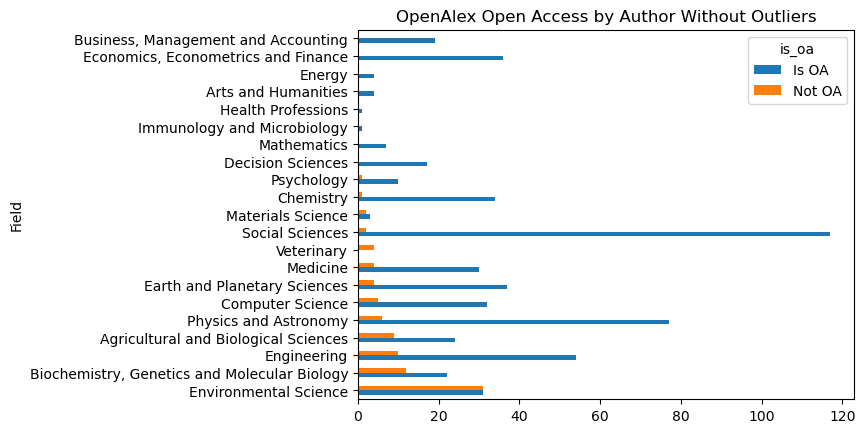

In [83]:
new_field_df.plot(x="Field", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Author Without Outliers')

In [84]:
new_subfield_df = counts('subfield_name','is_oa', 'OA %', remove_authors_df).sort_values(by=[True], ascending=False).reset_index(drop=True)
new_subfield_df = new_subfield_df.rename(columns={False: 'Not OA', True: 'Is OA',  'subfield_name': 'Subfield'})
#new_subfield_df = new_subfield_df[['subjectType', 'OpenAlex']]
new_subfield_df.head(20)
# remove_authors_df

is_oa,Subfield,Not OA,Is OA,OA %,Total
0,Astronomy and Astrophysics,2.0,57.0,0.966102,59.0
1,Sociology and Political Science,0.0,41.0,1.000000,41.0
2,Political Science and International Relations,1.0,32.0,0.969697,33.0
3,Spectroscopy,0.0,27.0,1.000000,27.0
4,Molecular Biology,2.0,21.0,0.913043,23.0
5,Atmospheric Science,2.0,18.0,0.900000,20.0
6,Plant Science,2.0,17.0,0.894737,19.0
7,Economics and Econometrics,0.0,16.0,1.000000,16.0
8,Ocean Engineering,0.0,16.0,1.000000,16.0
9,Strategy and Management,0.0,15.0,1.000000,15.0


Text(0.5, 1.0, 'OpenAlex Open Access by SubField')

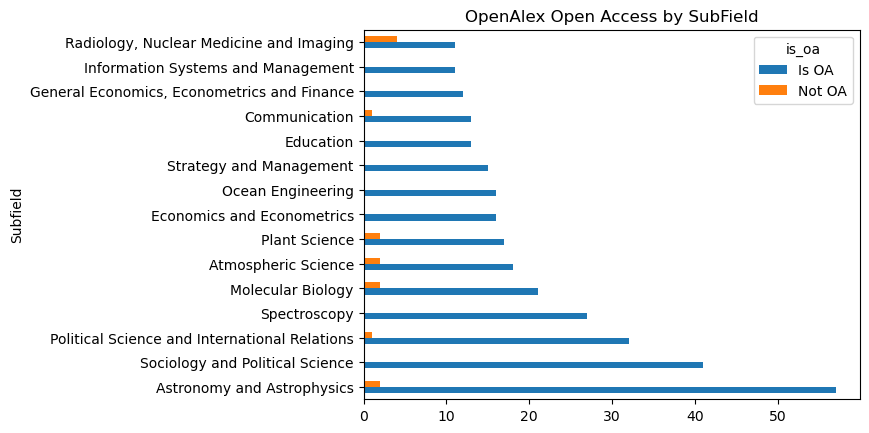

In [85]:
new_subfield_df.head(15).plot(x="Subfield", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by SubField')

In [86]:
new_subfield_df['Total'].sum()

651.0

In [87]:
new_field_df['Is OA'].sum() + new_field_df['Not OA'].sum()

651.0

In [88]:
new_field_df['Is OA'].sum()

560.0

In [89]:
new_field_df['Not OA'].sum()

91.0

In [90]:
MN_df

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
6,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5016996755,Claire Porter,first,https://orcid.org/0009-0005-4979-9778,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
7,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5074382278,Paul Morin,middle,https://orcid.org/0000-0002-4512-0642,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
9,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5114168374,Cole Kelleher,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
10,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5111210501,Michael Cloutier,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
11,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5098790376,Eric Husby,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517323,https://openalex.org/W4398340829,https://doi.org/10.7910/dvn/awsqtw,dataset,funder,Replication Data for: Parties as Disciplinaria...,2021,2021-01-01,en,https://openalex.org/T10557,Social Media and Politics,https://openalex.org/subfields/3315,Communication,https://openalex.org/fields/33,Social Sciences,https://openalex.org/domains/2,Social Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,

In [91]:
mn_status_df = oa_status(MN_df, 'publication_year', 'oa_status', 'publication_year')
mn_status_df

oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2024,0.0,16.0,5.0,0.0,0.0,21.0,0.000000,0.000000,0.238095,0.761905,0.000000,closed
1,2023,0.0,14.0,57.0,0.0,0.0,71.0,0.000000,0.000000,0.802817,0.197183,0.000000,gold
2,2022,0.0,229.0,148.0,0.0,0.0,377.0,0.000000,0.000000,0.392573,0.607427,0.000000,closed
3,2021,0.0,0.0,53.0,0.0,0.0,53.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold
4,2020,0.0,10.0,142.0,0.0,2.0,154.0,0.012987,0.000000,0.922078,0.064935,0.000000,gold
5,2019,0.0,8.0,104.0,0.0,0.0,112.0,0.000000,0.000000,0.928571,0.071429,0.000000,gold
6,2018,1.0,5.0,103.0,1.0,0.0,110.0,0.000000,0.009091,0.936364,0.045455,0.009091,gold
7,2017,6.0,6.0,2.0,0.0,0.0,14.0,0.000000,0.000000,0.142857,0.428571,0.428571,closed
8,2016,26.0,10.0,0.0,0.0,3.0,39.0,0.076923,0.000000,0.000000,0.256410,0.666667,bronze
9,2015,0.0,0.0,4.0,0.0,0.0,4.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold


<Axes: xlabel='publication_year'>

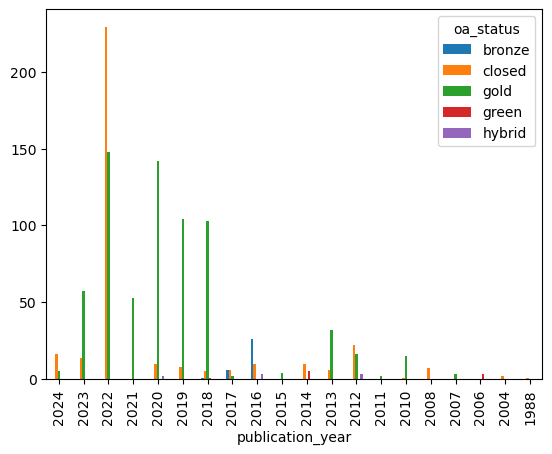

In [92]:
mn_status_plot = mn_status_df.plot(x="publication_year", y=["bronze", "closed", "gold", "green", "hybrid"], kind="bar")
mn_status_plot

## Plant Sciences    

In [93]:
plt_df = MN_df.groupby(['subfield_name'])['subfield_name'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
plt_df = plt_df.rename(columns={"count": "OpenAlex", "subfield_name": 'subjectType'})
plt_df = plt_df[['subjectType', 'OpenAlex']]
plt_df

,subjectType,OpenAlex
0,Computational Theory and Mathematics,111
1,Astronomy and Astrophysics,59
2,Sociology and Political Science,41
3,Molecular Biology,40
4,Political Science and International Relations,33
5,Spectroscopy,30
6,Pharmacology,29
7,Atmospheric Science,20
8,"Radiology, Nuclear Medicine and Imaging",19
9,Plant Science,19


In [94]:
MN_df['field_name'].unique()
# Agricultural and Biological Sciences
## Environmental Science, Biochemistry, Genetics and Molecular Biology


array(['Environmental Science', 'Earth and Planetary Sciences',
       'Engineering', 'Social Sciences', 'Computer Science',
       'Agricultural and Biological Sciences',
       'Biochemistry, Genetics and Molecular Biology', 'Medicine',
       'Economics, Econometrics and Finance', 'Physics and Astronomy',
       'Materials Science', 'Psychology', 'Mathematics',
       'Arts and Humanities', nan, 'Decision Sciences', 'Veterinary',
       'Chemistry', 'Business, Management and Accounting',
       'Immunology and Microbiology',
       'Pharmacology, Toxicology and Pharmaceutics', 'Energy',
       'Health Professions'], dtype=object)

In [ ]:
field_txt = MN_df
# only genetics subfield needed from biology one
# only Global and Planetary Change from es maybe Management, Monitoring, Policy and Law
field_txt = field_txt[(field_txt['field_name'] == 'Agricultural and Biological Sciences') | (field_txt['field_name'] == 'Environmental Science') | (field_txt['field_name'] == 'Biochemistry, Genetics and Molecular Biology')].reset_index(drop=True)

field_txt.to_csv('field_text.csv')

### subfield

In [96]:
MN_df['subfield_name'].unique()

# Plant Science, General Agricultural and Biological Sciences, Ecology, Evolution, Behavior and Systematics
## soil sience, Genetics, Food Science, Sustainability and the Environment, Nature and Landscape Conservation
### Developmental Biology, Cell Biology, Molecular Biology, Ecological Modeling
# ? nan

array(['Environmental Chemistry', 'Geochemistry and Petrology',
       'Atmospheric Science', 'Computational Mechanics',
       'Geography, Planning and Development',
       'Political Science and International Relations',
       'Global and Planetary Change', 'Artificial Intelligence',
       'Soil Science', 'Molecular Biology', 'Communication', 'Surgery',
       'Ocean Engineering', 'General Economics, Econometrics and Finance',
       'Computational Theory and Mathematics',
       'Astronomy and Astrophysics',
       'Radiology, Nuclear Medicine and Imaging',
       'Computer Vision and Pattern Recognition', 'Finance',
       'Materials Chemistry', 'Plant Science', 'Mechanics of Materials',
       'Gender Studies', 'Sociology and Political Science',
       'Aerospace Engineering', 'Economics and Econometrics',
       'Clinical Psychology', 'Genetics',
       'Electrical and Electronic Engineering', 'Software', 'Physiology',
       'Instrumentation', 'Earth-Surface Processes',
      

In [101]:
subfields_txt = MN_df
subfields_txt = subfields_txt[(subfields_txt['subfield_name'] == 'Plant Science') | (subfields_txt['subfield_name'] == 'General Agricultural and Biological Sciences') 
                              | (subfields_txt['subfield_name'] == 'Genetics') | (subfields_txt['subfield_name'] == 'Molecular Biology') | (subfields_txt['subfield_name'] == 'Renewable Energy, Sustainability and the Environment') | (subfields_txt['subfield_name'] == 'Global and Planetary Change from es maybe Management') ].reset_index(drop=True)
subfields_txt
subfields_txt.to_csv('subfield_text.csv')

In [98]:
MN_df['topic_name'].unique()

# Plant and animal studies, Botany and Plant Ecology Studies,  Genetic Mapping and Diversity in Plants and Animals, Mycorrhizal Fungi and Plant Interactions, Agricultural risk and resilience, Microbial Metabolic Engineering and Bioproduction, Microtubule and mitosis dynamics, Wheat and Barley Genetics and Pathology, Agriculture and Rural Development Research
## Soil Carbon and Nitrogen Dynamics, Molecular Biology Techniques and Applications, Insect Pest Control Strategies, Nutrition, Genetics, and Disease, Economics of Agriculture and Food Markets, Genetics, Bioinformatics, and Biomedical Research, Biochemical and Molecular Research, Algal biology and biofuel production
### Membrane-based Ion Separation Techniques, Microfluidic and Bio-sensing Technologies, Sustainable Development and Environmental Policy, CAR-T cell therapy research, Metabolism and Genetic Disorders, Enzyme Catalysis and Immobilization, Biotin and Related Studies, Water Quality and Resources Studies, Mediterranean and Iberian flora and fauna, Agricultural Economics and Policy

array(['Methane Hydrates and Related Phenomena',
       'Geological Modeling and Analysis',
       'Cryospheric studies and observations',
       'Astronomical Observations and Instrumentation',
       'Religious Tourism and Spaces',
       'American Constitutional Law and Politics',
       'Atmospheric and Environmental Gas Dynamics',
       'Quantum Information and Cryptography',
       'Soil Carbon and Nitrogen Dynamics',
       'Metabolism, Diabetes, and Cancer',
       'Media Studies and Communication',
       'Pancreatic function and diabetes',
       'Satellite Image Processing and Photogrammetry',
       'Global trade and economics',
       'Computational Drug Discovery Methods',
       'Gamma-ray bursts and supernovae', 'Retinal Imaging and Analysis',
       'Advanced Vision and Imaging',
       'Molecular Biology Techniques and Applications',
       'Agricultural risk and resilience', 'Social Media and Politics',
       'Financial Markets and Investment Strategies',
       'M

In [99]:
topic_txt = MN_df
topic_txt = topic_txt[(topic_txt['topic_name'] == 'Plant and animal studies') | (topic_txt['topic_name'] == 'Botany and Plant Ecology Studies') |(topic_txt['topic_name'] == 'Genetic Mapping and Diversity in Plants and Animals') |(topic_txt['topic_name'] == 'Microtubule and mitosis dynamics') |(topic_txt['topic_name'] == 'Wheat and Barley Genetics and Pathology') |(topic_txt['topic_name'] == 'Agriculture and Rural Development Research')
                      |(topic_txt['topic_name'] == 'Molecular Biology Techniques and Applications') |(topic_txt['topic_name'] == 'Insect Pest Control') |(topic_txt['topic_name'] == 'Algal biology and biofuel production') | (topic_txt['topic_name'] == 'Mediterranean and Iberian flora and fauna') ].reset_index(drop=True)
topic_txt


,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
0,https://openalex.org/W4391335905,https://doi.org/10.25581/spruce.110/1998878,dataset,funder,SPRUCE Quantitative PCR (qPCR) of microbial ge...,2024,2024-01-01,en,https://openalex.org/T11970,Molecular Biology Techniques and Applications,https://openalex.org/subfields/1312,Molecular Biology,https://openalex.org/fields/13,"Biochemistry, Genetics and Molecular Biology",https://openalex.org/domains/1,Life Sciences,False,NaN,OSTI OAI (U.S. Department of Energy Office of ...,False,closed,NaN,https://openalex.org/A5093800121,Zachary W. Buell,middle,NaN,https://openalex.org/I130238516,University of Minnesota,"University of Minnesota, Saint Paul, MN (Unite...",US,https://ror.org/017zqws13,https://openalex.org/I130238516
1,https://openalex.org/W4301224270,https://doi.org/10.5061/dryad.2mn50,dataset,funder,Data from: Shared genomic regions between deri...,2016,2016-06-01,en,https://openalex.org/T11468,Genetic Mapping and Diversity in Plants and An...,https://openalex.org/subfields/1311,Genetics,https://openalex.org/fields/13,"Biochemistry, Genetics and Molecular Biology",https://openalex.org/domains/1,Life Sciences,False,NaN,OSTI OAI (U.S. Department of Energy Office of ...,False,closed,NaN,https://openalex.org/A5063917020,Candice N. Hirsch,middle,https://orcid.org/0000-0002-8833-3023,https://openalex.org/I130238516,University of Minnesota,"Univ. of Minnesota, Minneapolis, MN (United St...",US,https://ror.org/017zqws13,https://openalex.org/I130238516
2,https://openalex.org/W4302799467,https://doi.org/10.5061/dryad.8vj84,dataset,funder,Data from: Draft assembly of elite inbred line...,2017,2017-11-01,en,https://openalex.org/T11468,Genetic Mapping and Diversity in Plants and An...,https://openalex.org/subfields/1311,Genetics,https://openalex.org/fields/13,"Biochemistry, Genetics and Molecular Biology",https://openalex.org/domains/1,Life Sciences,False,NaN,OSTI OAI (U.S. Department of Energy Office of ...,False,closed,NaN,https://openalex.org/A5063917020,Candice N. Hirsch,first,https://orcid.org/0000-0002-8833-3023,https://openalex.org/I130238516,University of Minnesota,"Univ. of Minnesota, Minneapolis, MN (United St...",US,https://ror.org/017zqws13,https://openalex.org/I130238516
3,https://openalex.org/W4302799467,https://doi.org/10.5061/dryad.8vj84,dataset,funder,Data from: Draft assembly of elite inbred line...,2017,2017-11-01,en,https://openalex.org/T11468,Genetic Mapping and Diversity in Plants and An...,https://openalex.org/subfields/1311,Genetics,https://openalex.org/fields/13,"Biochemistry, Genetics and Molecular Biology",https://openalex.org/domains/1,Life Sciences,False,NaN,OSTI OAI (U.S. Department of Energy Office of ...,False,closed,NaN,https://openalex.org/A5015912463,Cory D. Hirsch,middle,https://orcid.org/0000-0002-3409-758X,https://openalex.org/I130238516,University of Minnesota,"Univ. of Minnesota, Minneapolis, MN (United St...",US,https://ror.org/017zqws13,https://openalex.org/I130238516
4,https://openalex.org/W4302799467,https://doi.org/10.5061/dryad.8vj84,dataset,funder,Data from: Draft assembly of elite inbred line...,2017,2017-11-01,en,https://openalex.org/T11468,Genetic Mapping and Diversity in Plants and An...,https://openalex.org/subfields/1311,Genetics,https://openalex.org/fields/13,"Biochemistry, Genetics and Molecular Biology",https://openalex.org/domains/1,Life Sciences,False,NaN,OSTI OAI (U.S. Department of Energy Office of ...,False,closed,NaN,https://openalex.org/A5045350168,Alex B. Brohammer,middle,https://orcid.org/0000-0002-4639-4119,https://openalex.org/I130238516,University of Minnesota,"Univ. of Minnesota, Minneapolis, MN (United St...",US,https://ror.org/017zq

In [100]:
###  ,  Agricultural Economics and Policy